# 01. Exploratory Data Analysis

**Goal:** Get a first look at the dataset. Understand it's shape, types, missing values and class balance before moving to feature analysis.

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('../data/raw/high_diamond_ranked_10min.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9879 entries, 0 to 9878
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gameId                        9879 non-null   int64  
 1   blueWins                      9879 non-null   int64  
 2   blueWardsPlaced               9879 non-null   int64  
 3   blueWardsDestroyed            9879 non-null   int64  
 4   blueFirstBlood                9879 non-null   int64  
 5   blueKills                     9879 non-null   int64  
 6   blueDeaths                    9879 non-null   int64  
 7   blueAssists                   9879 non-null   int64  
 8   blueEliteMonsters             9879 non-null   int64  
 9   blueDragons                   9879 non-null   int64  
 10  blueHeralds                   9879 non-null   int64  
 11  blueTowersDestroyed           9879 non-null   int64  
 12  blueTotalGold                 9879 non-null   int64  
 13  blueAvgLevel  

### Observation:

- 40 features where "blueWins" is target. All the features are numerical ones: we can't see any string dtype feature.

In [4]:
df.shape

(9879, 40)

### Observation:

- Dataset has 9879 rows\examples with 40 columns\features.
- Sample size is reasonable for a baseline project. 40 features need to be checked: which ones are useful, which ones are not.

In [5]:
df.describe()

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
count,9.879000e+03,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,...,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000
mean,4.500084e+09,0.499038,22.288288,2.824881,0.504808,6.183925,6.137666,6.645106,0.549954,0.361980,...,0.043021,16489.041401,6.925316,17961.730438,217.349226,51.313088,-14.414111,33.620306,21.734923,1648.904140
std,2.757328e+07,0.500024,18.019177,2.174998,0.500002,3.011028,2.933818,4.064520,0.625527,0.480597,...,0.216900,1490.888406,0.305311,1198.583912,21.911668,10.027885,2453.349179,1920.370438,2.191167,149.088841
min,4.295358e+09,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,11212.000000,4.800000,10465.000000,107.000000,4.000000,-11467.000000,-8348.000000,10.700000,1121.200000
25%,4.483301e+09,0.000000,14.000000,1.000000,0.000000,4.000000,4.000000,4.000000,0.000000,0.000000,...,0.000000,15427.500000,6.800000,17209.500000,203.000000,44.000000,-1596.000000,-1212.000000,20.300000,1542.750000
50%,4.510920e+09,0.000000,16.000000,3.000000,1.000000,6.000000,6.000000,6.000000,0.000000,0.000000,...,0.000000,16378.000000,7.000000,17974.000000,218.000000,51.000000,-14.000000,28.000000,21.800000,1637.800000
75%,4.521733e+09,1.000000,20.000000,4.000000,1.000000,8.000000,8.000000,9.000000,1.000000,1.000000,...,0.000000,17418.500000,7.200000,18764.500000,233.000000,57.000000,1585.500000,1290.500000,23.300000,1741.850000
max,4.527991e+09,1.000000,250.000000,27.000000,1.000000,22.000000,22.000000,29.000000,2.000000,1.000000,...,2.000000,22732.000000,8.200000,22269.000000,289.000000,92.000000,10830.000000,9333.000000,28.900000,2273.200000


### Observation:

1. gameId column has a very high std (~2.7e+07), confirming it's a unique identifier rather than a meaningful feature. Will drop it before training.
2. redGoldDiff, redExperienceDiff have negative values what is understandable: these features represent the difference 'redTeam' - 'blueTeam'. Negative values mean the blue team is ahead.. Before training it's needed to engineer such features.
3. No zero values in dataset what is additionally prooved by count = shape

### Observation: Distribution of diff-features is skewed

Features like `blueGoldDiff` and `blueExperienceDiff` show wide ranges 
(std ≈ 2.2k for gold diff), indicating the dataset includes both close 
matches and stomps where one team dominates.

This skew is expected in League of Legends data — stomps are a real 
game scenario, not noise. We should NOT drop these examples. 
Tree-based models (RF, LightGBM) handle skewed distributions natively.
For linear models (logistic regression), consider log-transforming features.

In [6]:
nulls = df.isnull().sum()
print(nulls)

gameId                          0
blueWins                        0
blueWardsPlaced                 0
blueWardsDestroyed              0
blueFirstBlood                  0
blueKills                       0
blueDeaths                      0
blueAssists                     0
blueEliteMonsters               0
blueDragons                     0
blueHeralds                     0
blueTowersDestroyed             0
blueTotalGold                   0
blueAvgLevel                    0
blueTotalExperience             0
blueTotalMinionsKilled          0
blueTotalJungleMinionsKilled    0
blueGoldDiff                    0
blueExperienceDiff              0
blueCSPerMin                    0
blueGoldPerMin                  0
redWardsPlaced                  0
redWardsDestroyed               0
redFirstBlood                   0
redKills                        0
redDeaths                       0
redAssists                      0
redEliteMonsters                0
redDragons                      0
redHeralds    

**Observation:** The dataset is fully populated — no missing values in any of the 40 columns. This simplifies preprocessing significantly.

In [32]:
print("Normalized:")
df['blueWins'].value_counts(normalize=True)

Normalized:


blueWins
0    0.500962
1    0.499038
Name: proportion, dtype: float64

In [33]:
print("\nAbsolute:")
df['blueWins'].value_counts()


Absolute:


blueWins
0    4949
1    4930
Name: count, dtype: int64

**Observation:** As we can see, the class balance is approximately 50/50.
It's additionally confirms that selected baseline is reasonable.

In [17]:
# Let's check out how many unique values we have at features because we obviously have boolean type features that dont't have dtype boolean.
df.nunique().sort_values()

blueWins                           2
blueFirstBlood                     2
blueHeralds                        2
blueDragons                        2
redHeralds                         2
redDragons                         2
redFirstBlood                      2
blueEliteMonsters                  3
redEliteMonsters                   3
redTowersDestroyed                 3
blueTowersDestroyed                5
blueAvgLevel                      17
redAvgLevel                       18
blueDeaths                        21
redKills                          21
redDeaths                         21
blueKills                         21
redWardsDestroyed                 25
blueWardsDestroyed                27
redAssists                        28
blueAssists                       30
blueTotalJungleMinionsKilled      74
redTotalJungleMinionsKilled       75
blueWardsPlaced                  147
blueCSPerMin                     148
blueTotalMinionsKilled           148
redWardsPlaced                   151
r

## Feature Distributions

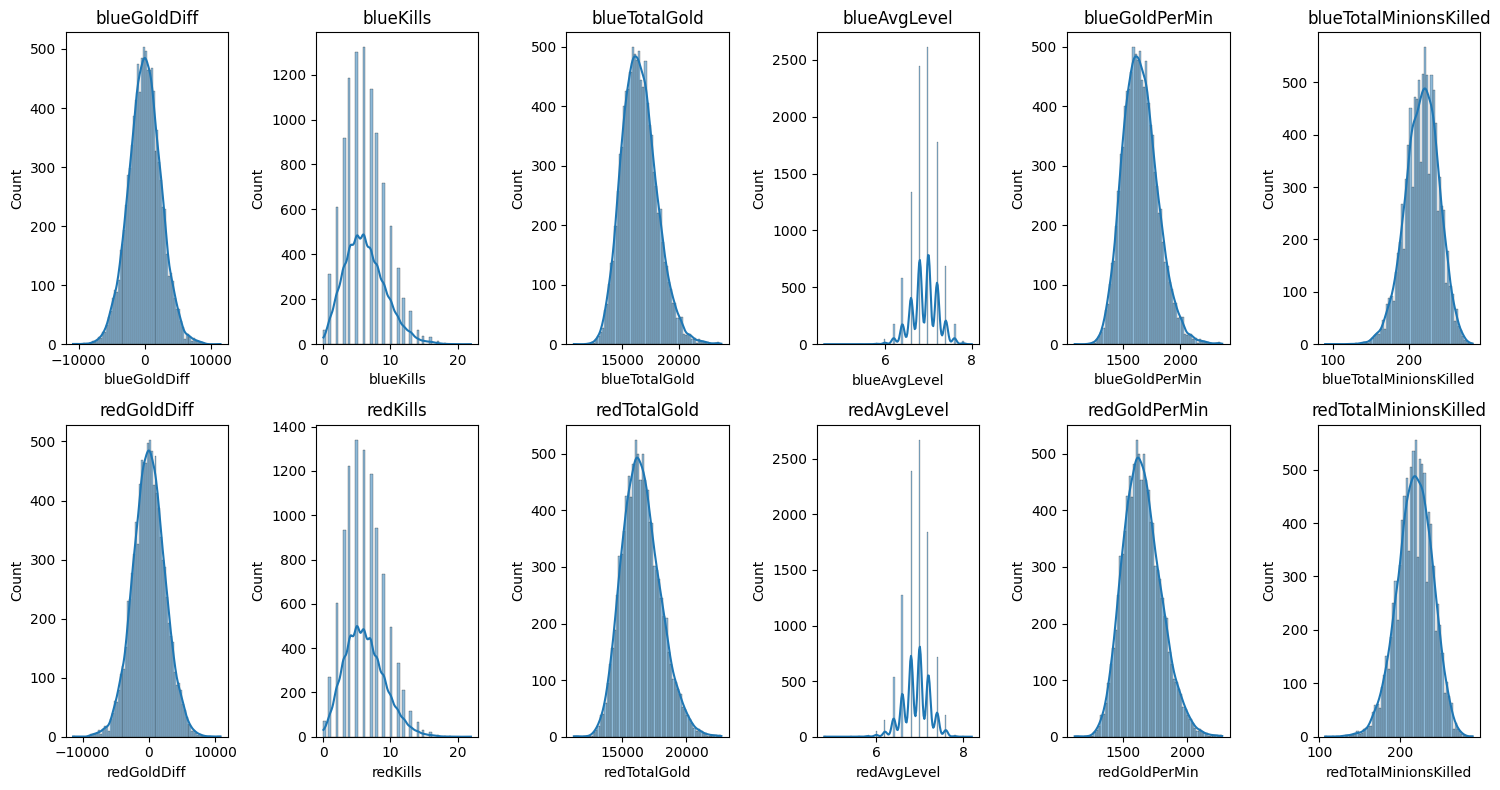

In [30]:
# Graphs about blueTeam and redTeam most important features
columns_to_plot_blues = ['blueGoldDiff', 'blueKills', 'blueTotalGold', 'blueAvgLevel', 'blueGoldPerMin', 'blueTotalMinionsKilled']
columns_to_plot_reds = ['redGoldDiff', 'redKills', 'redTotalGold', 'redAvgLevel', 'redGoldPerMin', 'redTotalMinionsKilled']
columns_to_plot = columns_to_plot_blues + columns_to_plot_reds

fig, axes = plt.subplots(2, 6, figsize = (15, 8))
axes = axes.flatten()

for i, col in enumerate(columns_to_plot):
    sns.histplot(df[col], ax=axes[i], kde=True)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

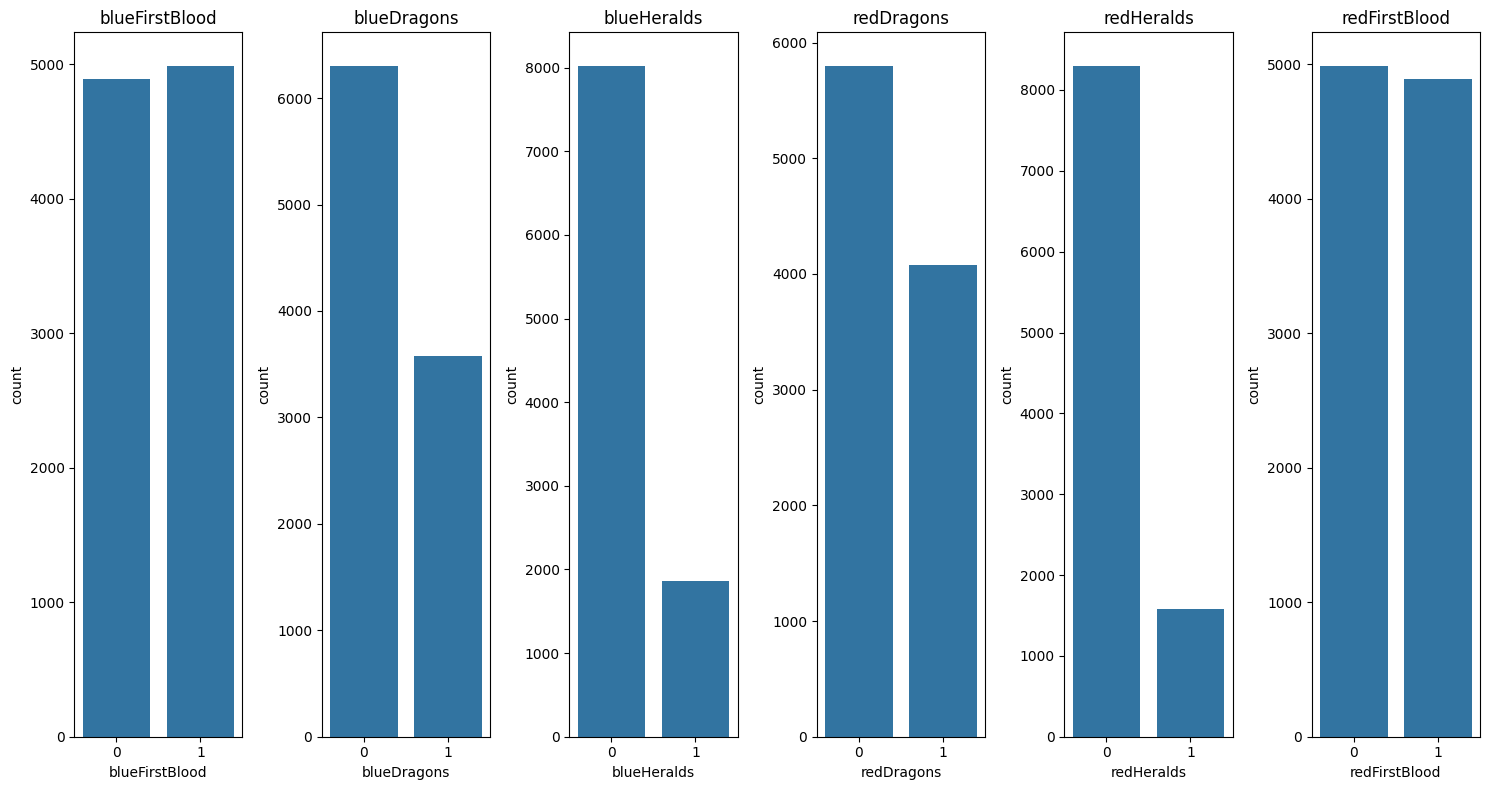

In [29]:
discrete_cols = ['blueFirstBlood', 'blueDragons', 'blueHeralds', 'redDragons', 'redHeralds', 'redFirstBlood']
fig, axes = plt.subplots(1, len(discrete_cols), figsize = (15, 8))
axes = axes.flatten()

for i, col in enumerate(discrete_cols):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

## Correlation Analysis

In [28]:
# Let's check correlation of target feature with other features

df.corr()['blueWins'].abs().sort_values(ascending=False)

blueWins                        1.000000
blueGoldDiff                    0.511119
redGoldDiff                     0.511119
redExperienceDiff               0.489558
blueExperienceDiff              0.489558
blueTotalGold                   0.417213
blueGoldPerMin                  0.417213
redTotalGold                    0.411396
redGoldPerMin                   0.411396
blueTotalExperience             0.396141
redTotalExperience              0.387588
blueAvgLevel                    0.357820
redAvgLevel                     0.352127
redKills                        0.339297
blueDeaths                      0.339297
blueKills                       0.337358
redDeaths                       0.337358
blueAssists                     0.276685
redAssists                      0.271047
blueCSPerMin                    0.224909
blueTotalMinionsKilled          0.224909
blueEliteMonsters               0.221944
redEliteMonsters                0.221551
blueDragons                     0.213768
redTotalMinionsK

### Key Insight: Feature Duplication

Multiple features appear in mirrored pairs with identical absolute correlations 
with the target:
- `blueGoldDiff` ≈ `redGoldDiff` = 0.511 — these are the same variable 
  with opposite signs (blueGold - redGold vs redGold - blueGold)
- `blueKills` ≈ `redDeaths` = 0.337 — by definition, blue's kills equal red's deaths
- `blueExperienceDiff` ≈ `redExperienceDiff`

**Implications:**
- High multicollinearity is expected in the correlation matrix.
- For linear models (logistic regression), these redundant features can 
  cause unstable coefficients — consider dropping one side of each pair.
- Tree-based models (Random Forest, LightGBM) are robust to this.

### Hypothesis Check

**Prior expectations (as a League of Legends player):**
1. Gold-related features should dominate — **CONFIRMED** (top 6 by correlation)
2. Kills are important but not the strongest — **CONFIRMED** (0.34, behind gold/exp)
3. Wards placed count should be weak — **CONFIRMED** (0.00009, virtually no signal)
4. First Blood should matter — **PARTIALLY CONFIRMED** (0.20, moderate predictor)

**Insight on Wards:**
The near-zero correlation of `blueWardsPlaced` with victory is striking. 
In-game, vision quality > vision quantity. A single deep ward can be more 
valuable than 10 defensive wards. The feature "how many wards were placed" 
does not capture this spatial component.

This is a **feature engineering opportunity**: derived features like 
"wards placed in enemy jungle" would likely have much higher predictive power.

### Insight: Diff Features > Absolute Features

`blueGoldDiff` (0.51) correlates with victory more strongly than `blueTotalGold` (0.42).
This makes intuitive sense: winning depends on **relative** advantage, not absolute resources.

Feature engineering opportunity: create additional diff features explicitly, e.g. 
`kills_diff = blueKills - redKills`. Such features could boost linear model performance 
without adding information already present in tree-based models.